In [1]:
# sensitivity test for CLM5 parameters (21) accross the Continental US
# Import the required libraries
import csv
import functools
import math
import sys
import time
import random
import warnings
import subprocess
import argparse

# sys.path.append('C:/Users/hx293/Research_Data/BINN/')
# sys.path.append('/glade/u/home/haodixu/BINN')
# sys.path.append(r'/User/homes/ftao/Projects/BINNS/src_binns')
sys.path.append('/glade/work/haodixu/BINN')

# Set HDF5_DISABLE_VERSION_CHECK to suppress version mismatch error
import os
os.environ['HDF5_DISABLE_VERSION_CHECK'] = '2'
import psutil
import gc

from datetime import datetime, timedelta
import pandas as pd
from pandas import DataFrame as df
import numpy as np
from scipy.interpolate import pchip_interpolate
# parallel computing
# import concurrent.futures
# import torch.multiprocessing as mp
# # initialize the multiprocessing for pytorch
# mp.set_start_method('spawn', force=True)
print("Start binns_DDP")

import os
import torch



from scipy.io import loadmat
import netCDF4 as ncread 
import mat73

from matplotlib import pyplot as plt
from matplotlib.patches import Patch
from collections import OrderedDict

# Define input and output directories
# input_dir = 'D:/Research/BINN/BINN_output/Sensitivity_Test_1000_Random_Seed_12355/'
# data_dir_output = 'D:/Research/BINN/BINN_output/Sensitivity_Test_1000_Random_Seed_12355/'
input_dir = 'D:/Research/BINN/BINN_output/Sensitivity_Test_1000_stock/'
data_dir_output = 'D:/Research/BINN/BINN_output/Sensitivity_Test_1000_stock/'

Start binns_DDP


245
   parameters  sensitivity  sensitivity_std
4      taucwd     0.001085         0.000403
7      tau4s1     0.001087         0.000410
1        cryo     0.001100         0.000435
5       taul1     0.001115         0.000453
6       taul2     0.001115         0.000427
17      fs3s1     0.001144         0.000467
18     fcwdl2     0.001161         0.000476
8      tau4s2     0.001639         0.000840
10      fl1s1     0.001980         0.000571
15      fs2s1     0.002277         0.000551
12      fl3s2     0.003413         0.000964
13      fs1s2     0.004447         0.001878
11      fl2s1     0.005639         0.002041
16      fs2s3     0.006603         0.001922
0      diffus     0.009924         0.006288
2         q10     0.014636         0.011680
14      fs1s3     0.026423         0.008564
9      tau4s3     0.068291         0.037792
3    efolding     0.172965         0.117166
19  w-scaling     0.377104         0.349097
20       beta     0.662453         2.216585


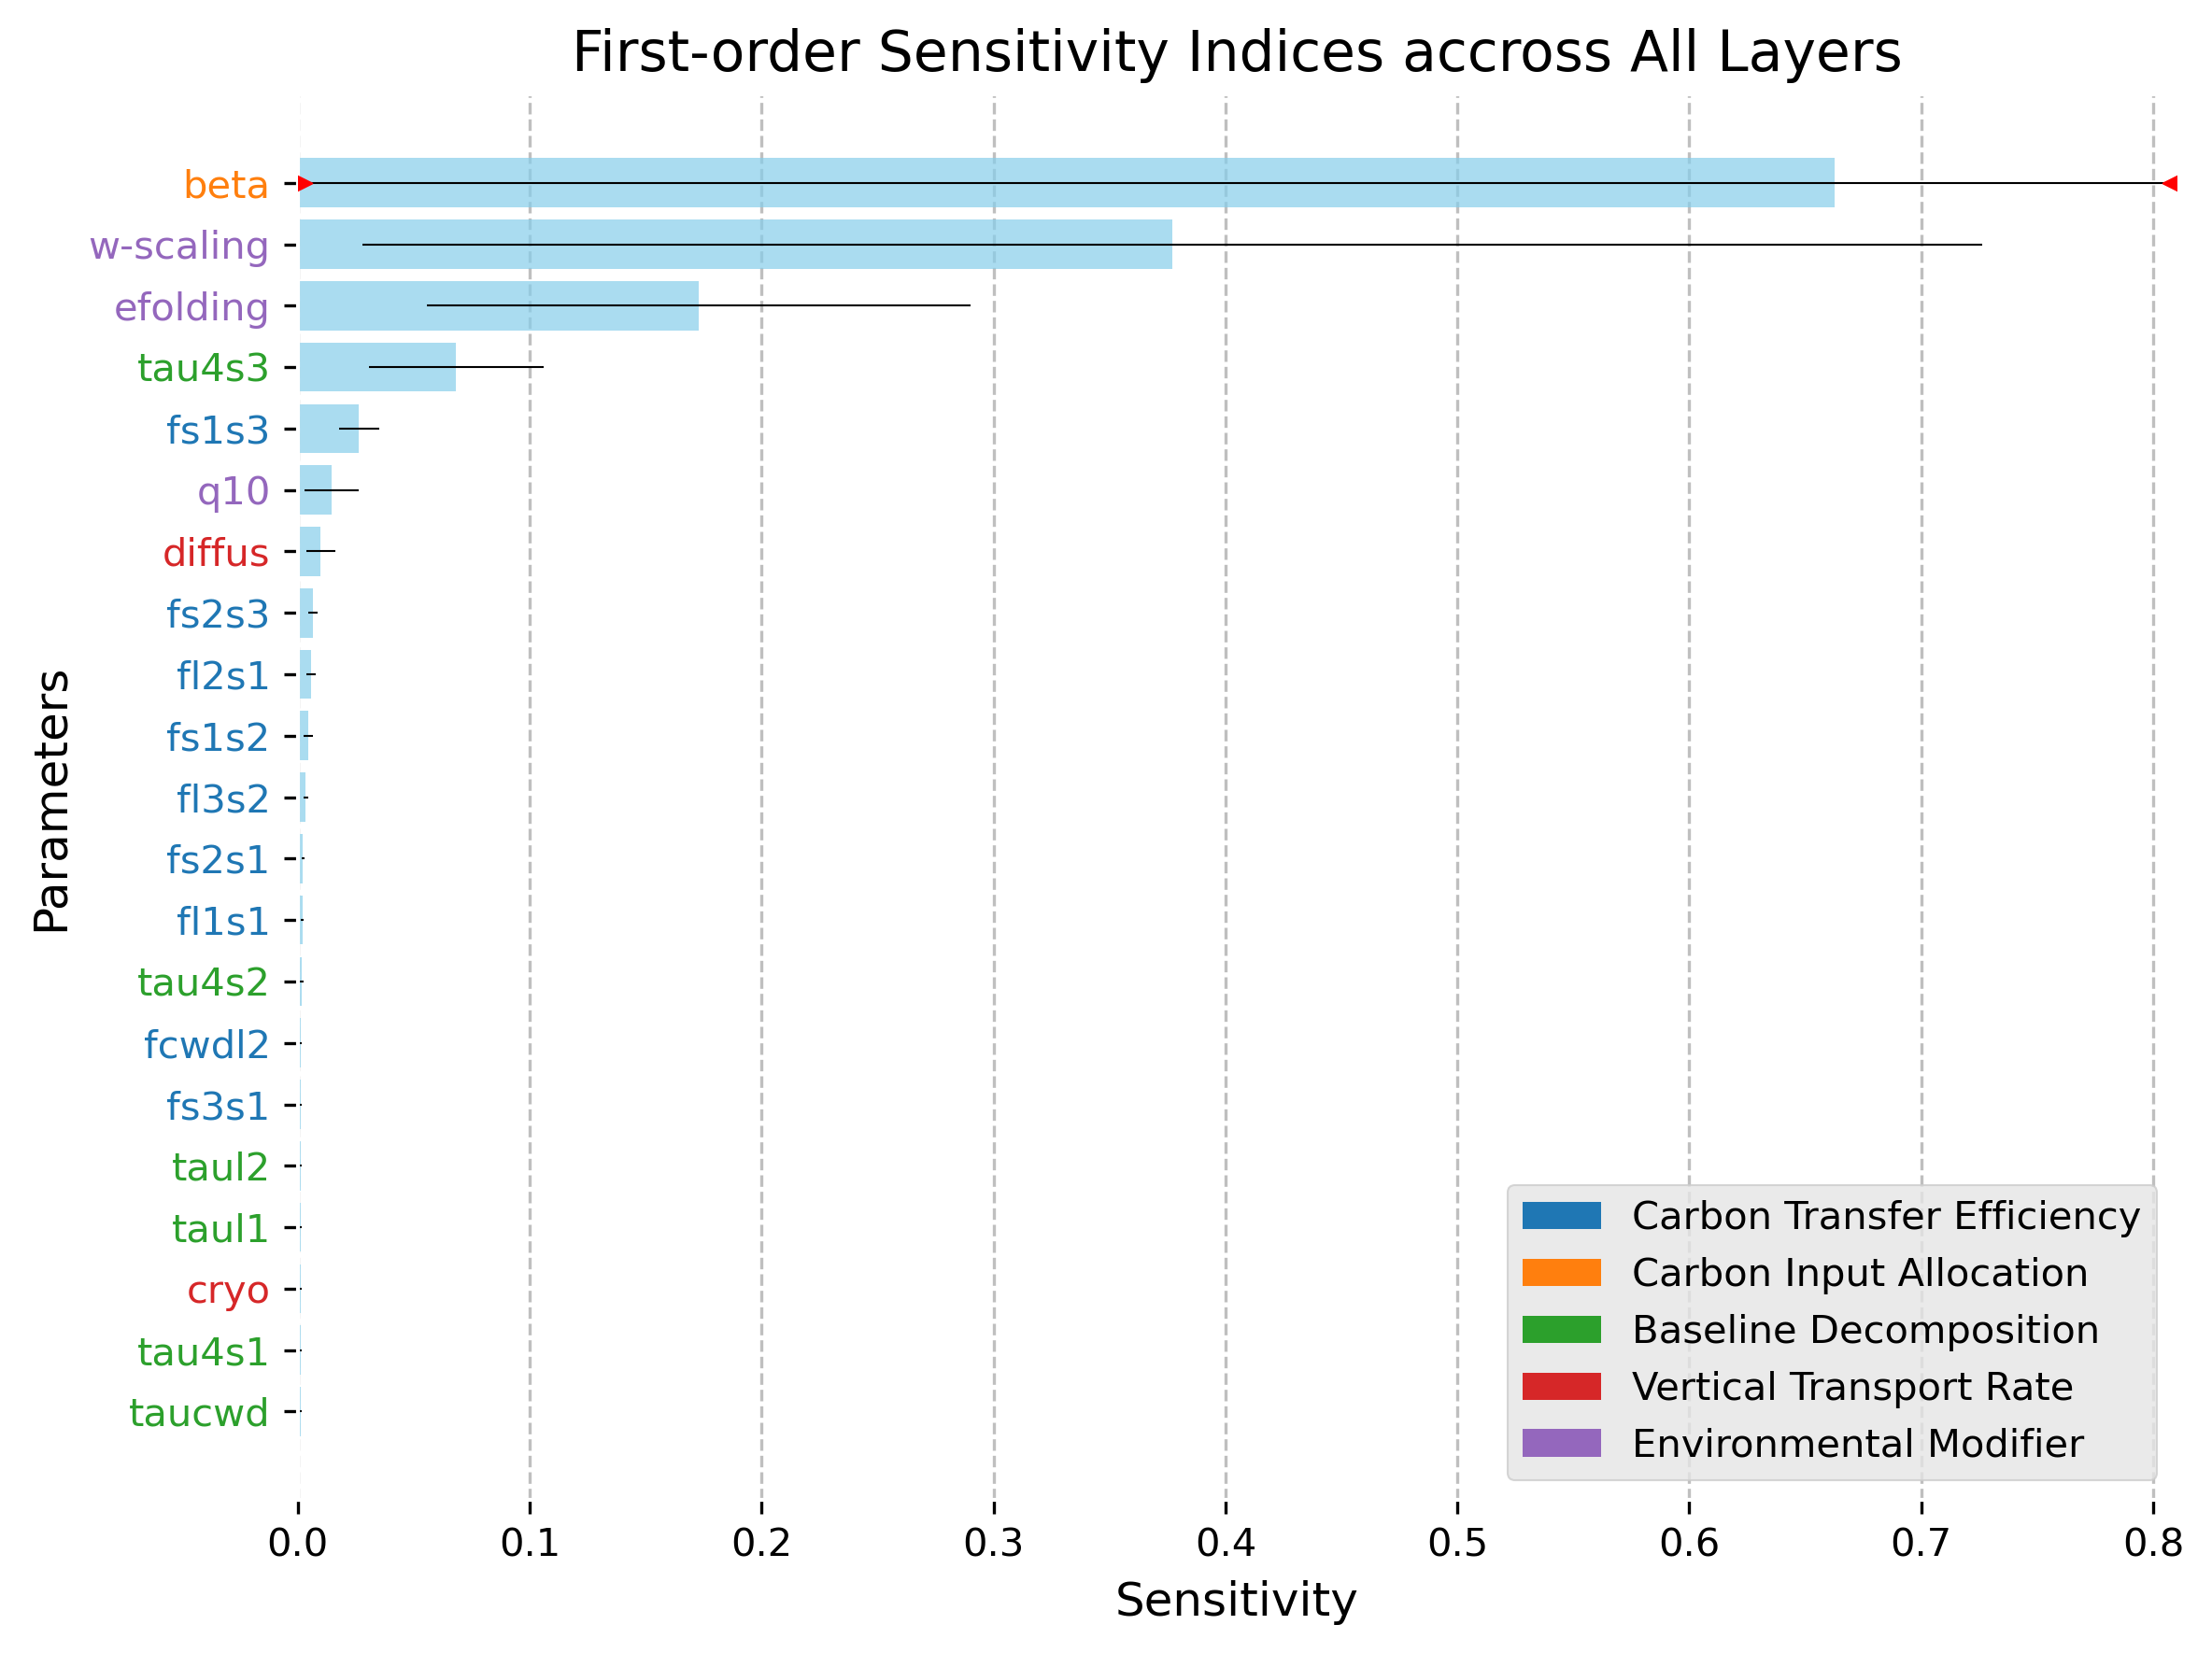

sensitivity_soc_all_sensitivity.png has been saved!


In [3]:
# Define the parameter names
para_names = ['diffus', 'cryo', 'q10', 'efolding', 'taucwd', 'taul1', 'taul2', 'tau4s1', 'tau4s2', 'tau4s3', 'fl1s1', 'fl2s1', 'fl3s2', 'fs1s2', 'fs1s3', 'fs2s1', 'fs2s3', 'fs3s1', 'fcwdl2', 'w-scaling', 'beta']
input_matrix = ['bulk_A', 'bulk_I', 'bulk_K', 'bulk_V', 'bulk_xi']
matrix_names = ['Carbon Transfer Efficiency', 'Carbon Input Allocation', 'Baseline Decomposition', 'Vertical Transport Rate', 'Environmental Modifier']
matrix_color = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
# Assign parameter to each matrix
matrix_para = {'bulk_A': ['fl1s1', 'fl2s1', 'fl3s2', 'fs1s2', 'fs1s3', 'fs2s1', 'fs2s3', 'fs3s1', 'fcwdl2'],
			   'bulk_I': ['beta'],
			   'bulk_K': ['taucwd', 'taul1', 'taul2', 'tau4s1', 'tau4s2', 'tau4s3'],
			   'bulk_V': ['diffus', 'cryo'],
			   'bulk_xi': ['q10', 'efolding', 'w-scaling']}
# Helper function to load color for each matrix
matrix_key_to_color = dict(zip(input_matrix, matrix_color))
matrix_key_to_pretty = dict(zip(input_matrix, matrix_names))

param_to_matrix = {}
for mkey, plist in matrix_para.items():
    for p in plist:
        param_to_matrix[p] = mkey

def _param_color(p):
    mkey = param_to_matrix.get(p, None)
    return matrix_key_to_color.get(mkey, "#555555")

def _param_matrix_name(p):
    mkey = param_to_matrix.get(p, None)
    return matrix_key_to_pretty.get(mkey, "Unassigned")

# Load parameter variance from csv and plot the bar chart
for i in range(1, 8):
	if i == 1:
		para_var_all = pd.read_csv(input_dir + 'sensitivity_soc_all_sensitivity_' + str(i) + '.csv')
		# Remove the first column
		para_var_all = para_var_all.drop(columns = ['Unnamed: 0'])
	else:
		para_var_all = pd.concat([para_var_all, pd.read_csv(input_dir + 'sensitivity_soc_all_sensitivity_' + str(i) + '.csv').drop(columns = ['Unnamed: 0'])], axis = 1)

# Rename the columns to 0-20
para_var_all.columns = range(len(para_names))
# Drop all the rows with NaN and Inf
para_var_all = para_var_all.replace([np.inf, -np.inf], np.nan).dropna()
# print the length of the dataframe
print(len(para_var_all))
# Calculate the mean value of each column
para_var_all_mean = para_var_all.mean()
# Create a dataframe to store the mean value and the parameter names
para_var_all_mean = pd.DataFrame(para_names, columns = ['parameters'])
para_var_all_mean['sensitivity'] = para_var_all.mean().values
# Create a dataframe to store the std value and the parameter names
para_var_all_std = pd.DataFrame(para_names, columns = ['parameters'])
para_var_all_std['sensitivity_std'] = para_var_all.std().values
# Merge the two dataframes
para_var_all_mean = pd.merge(para_var_all_mean, para_var_all_std, on = 'parameters')
# print(para_var_all_mean)
# print(para_var_all_mean)
# Sort the mean value in descending order
para_var_all_mean = para_var_all_mean.sort_values(by = 'sensitivity', ascending = True)
print(para_var_all_mean)

# Clipped ends of error bars
lower = para_var_all_mean['sensitivity'] - para_var_all_mean['sensitivity_std']
upper = para_var_all_mean['sensitivity'] + para_var_all_mean['sensitivity_std']
x_min = 0.0
x_max = 0.81
lower_clip = np.maximum(lower, x_min)
upper_clip = np.minimum(upper, x_max)
left_err_draw = np.clip(para_var_all_mean['sensitivity'] - lower_clip, 0, None)
right_err_draw = np.clip(upper_clip - para_var_all_mean['sensitivity'], 0, None)
xerr_draw = np.vstack([left_err_draw, right_err_draw])

# Create a horizontal bar chart
# Set the resolution of the figure
fig, ax = plt.subplots(figsize = (8, 6), dpi = 300)
plt.style.use('ggplot')
ax.barh(para_var_all_mean['parameters'], para_var_all_mean['sensitivity'], alpha = 0.7, color = 'skyblue')
ax.errorbar(para_var_all_mean['sensitivity'], para_var_all_mean['parameters'], xerr = xerr_draw, ecolor = 'black', elinewidth = 0.5, capsize = 0.0, fmt = 'none')
# --- Add red dots where clipping happens ---
mask_left_clipped = lower < x_min
mask_right_clipped = upper > x_max

if mask_left_clipped.any():
    ax.scatter(
        np.full(mask_left_clipped.sum(), x_min),
        para_var_all_mean['parameters'][mask_left_clipped],
        color='red',
        s=50,
        zorder=3,
        marker = '>'
    )
if mask_right_clipped.any():
    ax.scatter(
        np.full(mask_right_clipped.sum(), x_max),
        para_var_all_mean['parameters'][mask_right_clipped],
        color='red',
        s=50,
        zorder=3,
        marker = '<'
    )

# Add labels and title
ax.set_xlabel('Sensitivity')
ax.set_ylabel('Parameters')
ax.set_title('First-order Sensitivity Indices accross All Layers')
# Set x-axis limit
ax.set_xlim(x_min, x_max)
# Blank background color
ax.set_facecolor('white')
# Text color to black
ax.tick_params(axis = 'x', colors = 'black')
ax.tick_params(axis = 'y', colors = 'black')
# Axis subtitle color to black
ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')
# Add grid lines only for x-axis
ax.xaxis.grid(True, linestyle = '--', which = 'major', color = 'grey', alpha = 0.5)
ax.yaxis.grid(False)
# Draw a red dash line at x = 0.2
# ax.axvline(x = 0.02, color = 'r', linestyle = '--')

# --- color each y-tick label by its matrix color ---
# Ensure ticks are drawn before we edit them
fig.canvas.draw()
yticklabels = ax.get_yticklabels()
for lab in yticklabels:
    p = lab.get_text()
    lab.set_color(_param_color(p))

# --- add legend explaining the colors ---
legend_handles = [Patch(facecolor=matrix_key_to_color[k], edgecolor='none', label=matrix_key_to_pretty[k])
                  for k in input_matrix]
# Include an "Unassigned" bucket if any parameter is missing mapping
if any(p not in param_to_matrix for p in para_var_all_mean['parameters']):
    legend_handles.append(Patch(facecolor="#555555", edgecolor='none', label="Unassigned"))

leg = ax.legend(handles=legend_handles, frameon=True, loc='lower right')
leg._legend_box.align = "left"

plt.tight_layout()
plt.show()

# Save the figure
fig.savefig(data_dir_output + 'sensitivity_soc_all_sensitivity.png')
print('sensitivity_soc_all_sensitivity.png has been saved!')
# Print out the index of the parameters with sensitivity larger than 0.02
# print(para_var_all_mean[para_var_all_mean > 0.02].index)
# Check the sum of the sensitivity
# print(para_var_all_mean.sum())



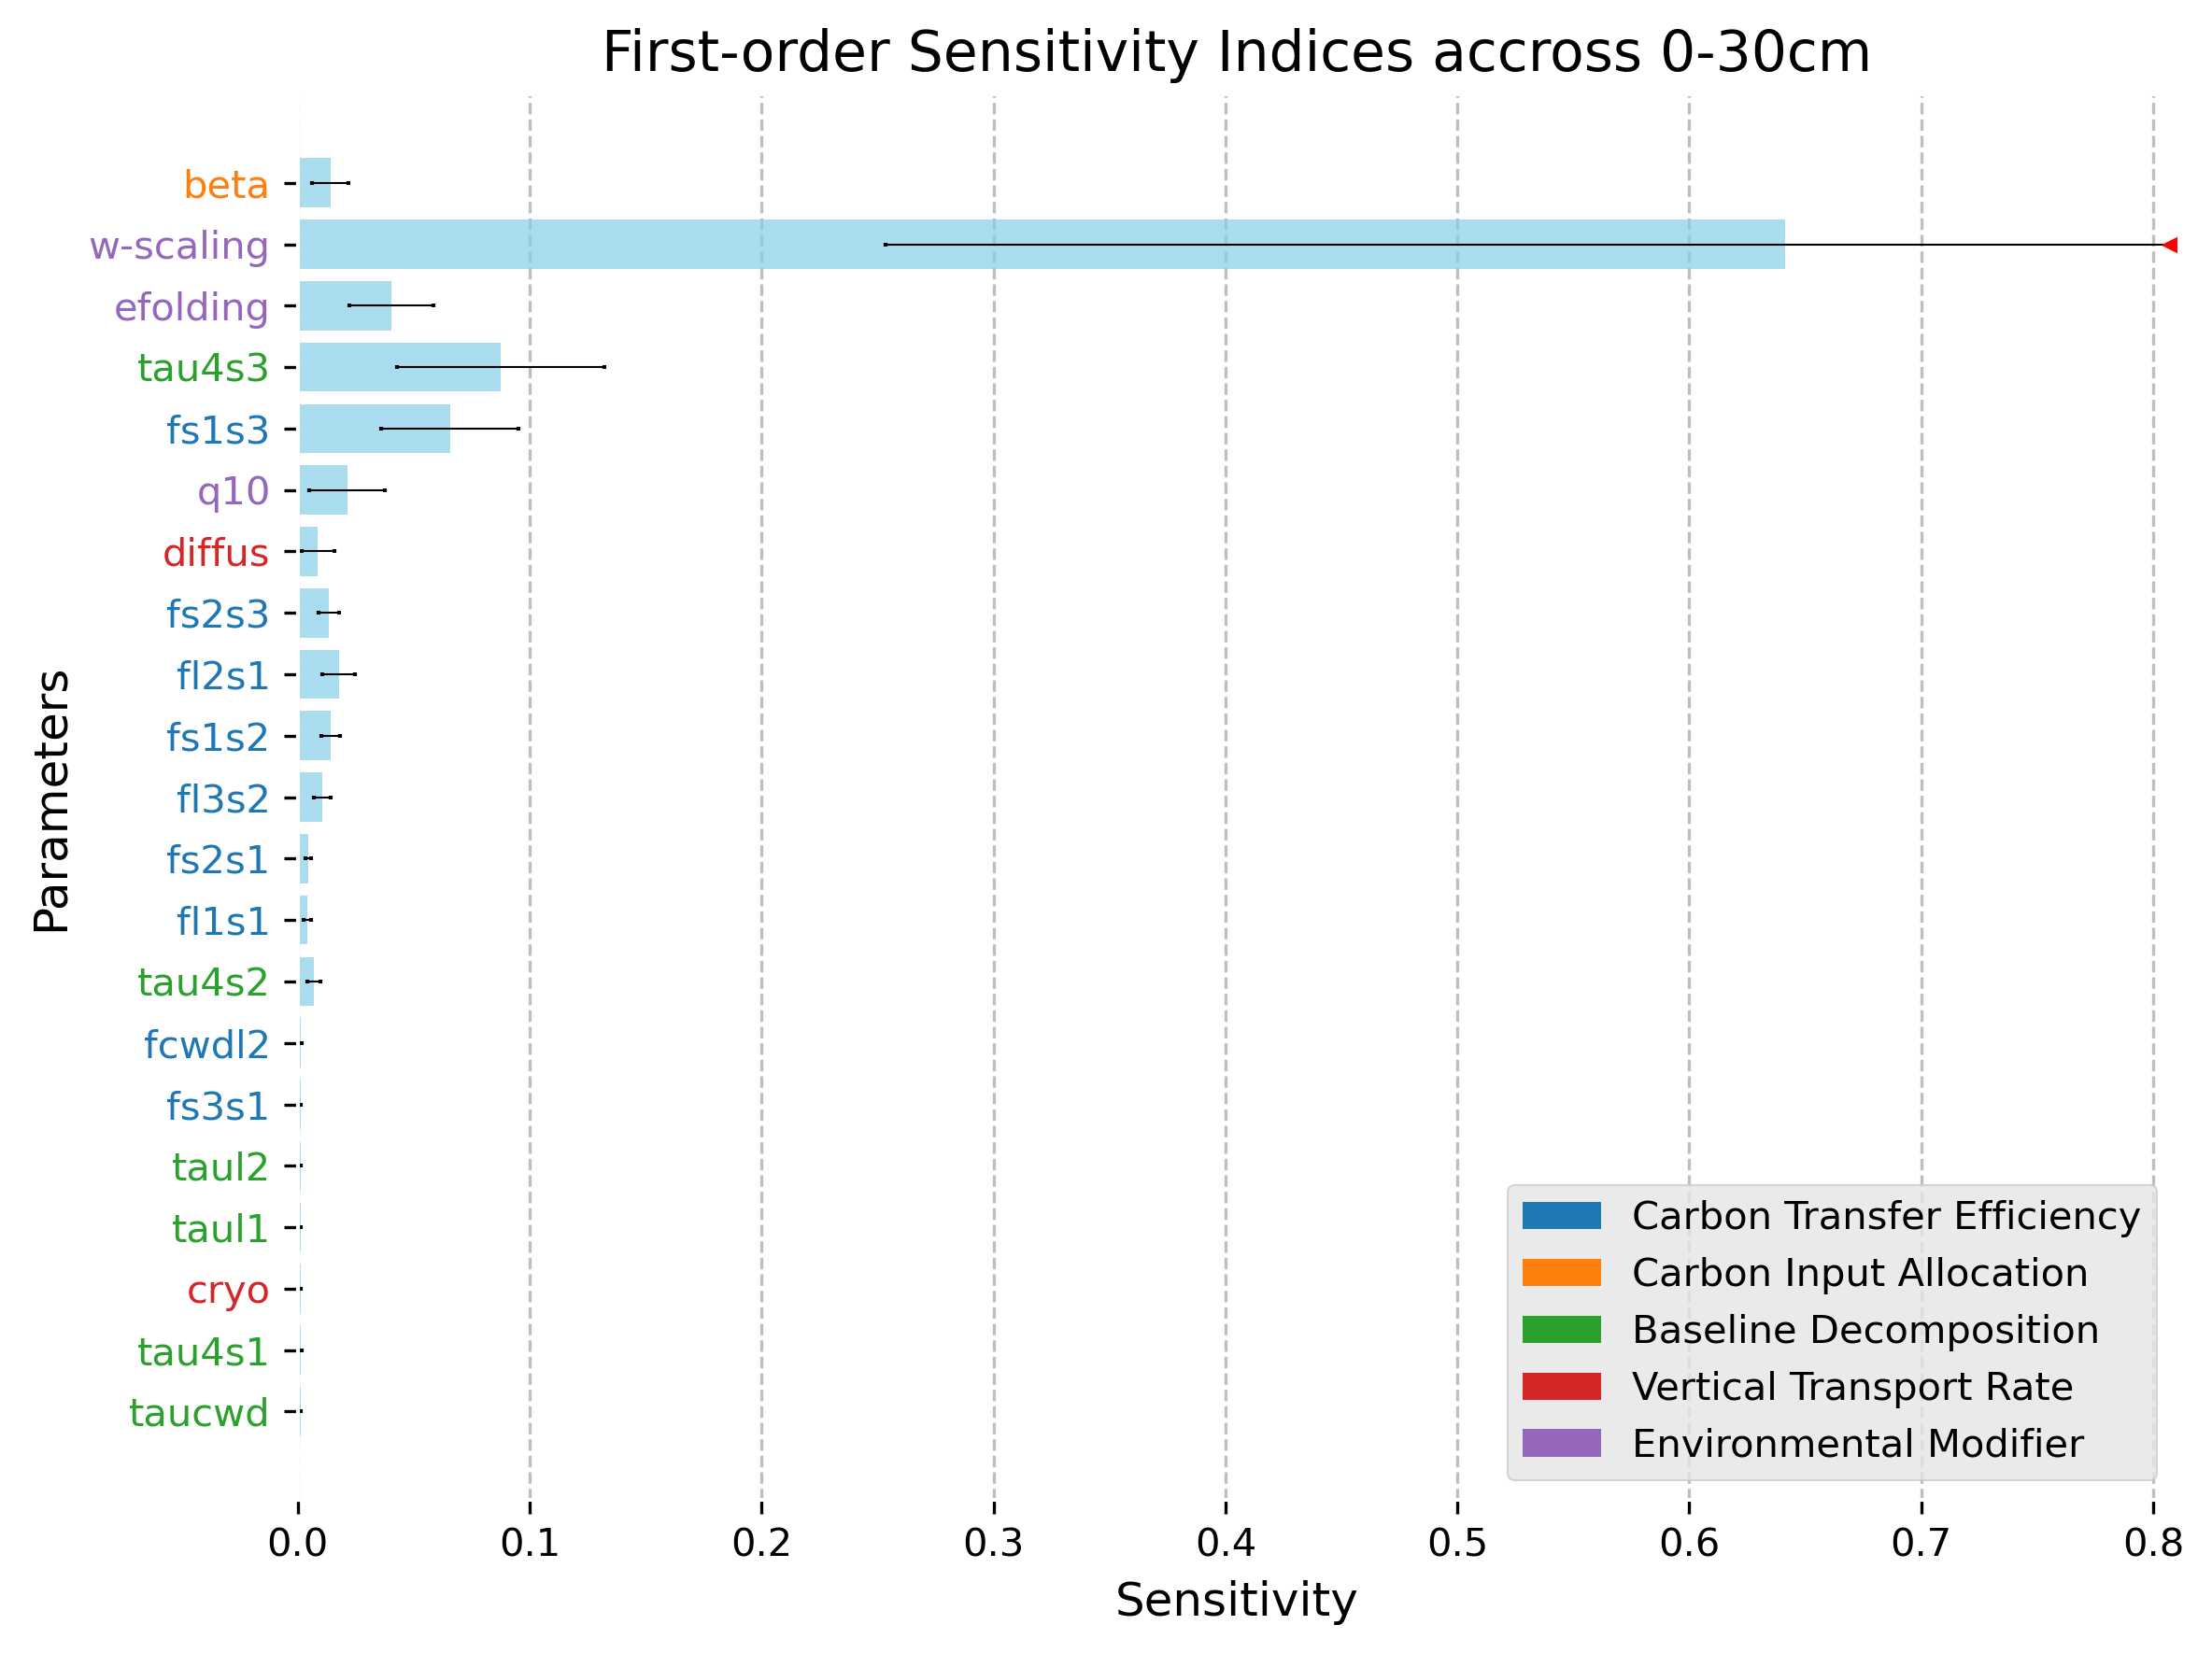

sensitivity_soc_0_30_sensitivity.png has been saved!
parameters          taucwdtau4s1cryotaul1taul2fs3s1fcwdl2tau4s2fl1...
sensitivity_all                                                1.3656
sensitivity_std                                              2.759012
sensitivity_0_30                                             0.958104
dtype: object


In [4]:
# Load parameter variance from csv and plot the bar chart
for i in range(1, 8):
	if i == 1:
		para_var_0_30 = pd.read_csv(input_dir + 'sensitivity_soc_0_30_sensitivity_' + str(i) + '.csv')
		para_var_0_30 = para_var_0_30.drop(columns = ['Unnamed: 0'])
	else:
		para_var_0_30 = pd.concat([para_var_0_30, pd.read_csv(input_dir + 'sensitivity_soc_0_30_sensitivity_' + str(i) + '.csv').drop(columns = ['Unnamed: 0'])], axis = 1)
		# print("Length of para_var_0_30 in loop " + str(i) + " is " + str(len(para_var_0_30)))
# Rename the columns to 0-20
para_var_0_30.columns = range(len(para_names))
# Drop all the rows with NaN and Inf
para_var_0_30 = para_var_0_30.replace([np.inf, -np.inf], np.nan).dropna()
# Calculate the mean value of each column
para_var_0_30_mean = para_var_0_30.mean()
# Create a dataframe to store the mean value and the parameter names
para_var_0_30_mean = pd.DataFrame(para_names, columns = ['parameters'])
para_var_0_30_mean['sensitivity'] = para_var_0_30.mean().values
# Create a dataframe to store the std value and the parameter names
para_var_0_30_std = pd.DataFrame(para_names, columns = ['parameters'])
para_var_0_30_std['sensitivity_std'] = para_var_0_30.std().values
# Merge the two dataframes so that we can plot the second bar chart following the first one's order
para_var_0_30_mean = pd.merge(para_var_all_mean, para_var_0_30_mean, on = 'parameters', how = 'inner', suffixes = ('_all', '_0_30'))
para_var_0_30_plot = pd.merge(para_var_0_30_mean, para_var_0_30_std, on = 'parameters')

# Clipped ends of error bars
lower = para_var_0_30_plot['sensitivity_0_30'] - para_var_0_30_plot['sensitivity_std_y']
upper = para_var_0_30_plot['sensitivity_0_30'] + para_var_0_30_plot['sensitivity_std_y']
x_min = 0.0
x_max = 0.81
lower_clip = np.maximum(lower, x_min)
upper_clip = np.minimum(upper, x_max)
left_err_draw = np.clip(para_var_0_30_plot['sensitivity_0_30'] - lower_clip, 0, None)
right_err_draw = np.clip(upper_clip - para_var_0_30_plot['sensitivity_0_30'], 0, None)
xerr_draw = np.vstack([left_err_draw, right_err_draw])

# Create a horizontal bar chart
fig, ax = plt.subplots(figsize = (8, 6), dpi = 300)
plt.style.use('ggplot')
ax.barh(para_var_0_30_plot['parameters'], para_var_0_30_plot['sensitivity_0_30'], alpha = 0.7, color = 'skyblue')
ax.errorbar(para_var_0_30_plot['sensitivity_0_30'], para_var_0_30_plot['parameters'], xerr = para_var_0_30_plot['sensitivity_std_y'], ecolor = 'black', elinewidth = 0.5, capsize = 0.5, fmt = 'none')
# --- Add red dots where clipping happens ---
mask_left_clipped = lower < x_min
mask_right_clipped = upper > x_max

if mask_left_clipped.any():
    	ax.scatter(
		np.full(mask_left_clipped.sum(), x_min),
		para_var_0_30_plot['parameters'][mask_left_clipped],
		color='red',
		s=50,
		zorder=3,
		marker = '>'
	)
if mask_right_clipped.any():
	ax.scatter(
		np.full(mask_right_clipped.sum(), x_max),
		para_var_0_30_plot['parameters'][mask_right_clipped],
		color='red',
		s=50,
		zorder=3,
		marker = '<'
	)

# Add labels and title
ax.set_xlabel('Sensitivity')
ax.set_ylabel('Parameters')
ax.set_title('First-order Sensitivity Indices accross 0-30cm')
ax.set_xlim(x_min, x_max)
# Blank background color
ax.set_facecolor('white')
# Text color to black
ax.tick_params(axis = 'x', colors = 'black')
ax.tick_params(axis = 'y', colors = 'black')
# Axis subtitle color to black
ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')
# Add grid lines only for x-axis
ax.xaxis.grid(True, linestyle = '--', which = 'major', color = 'grey', alpha = 0.5)
ax.yaxis.grid(False)

# --- color each y-tick label by its matrix color ---
fig.canvas.draw()
yticklabels = ax.get_yticklabels()
for lab in yticklabels:
	p = lab.get_text()
	lab.set_color(_param_color(p))

leg = ax.legend(handles=legend_handles, frameon=True, loc='lower right')
leg._legend_box.align = "left"

plt.tight_layout()
plt.show()
# Save the figure
fig.savefig(data_dir_output + 'sensitivity_soc_0_30_sensitivity.png')
print('sensitivity_soc_0_30_sensitivity.png has been saved!')

# Check the sum of the sensitivity
print(para_var_0_30_mean.sum())



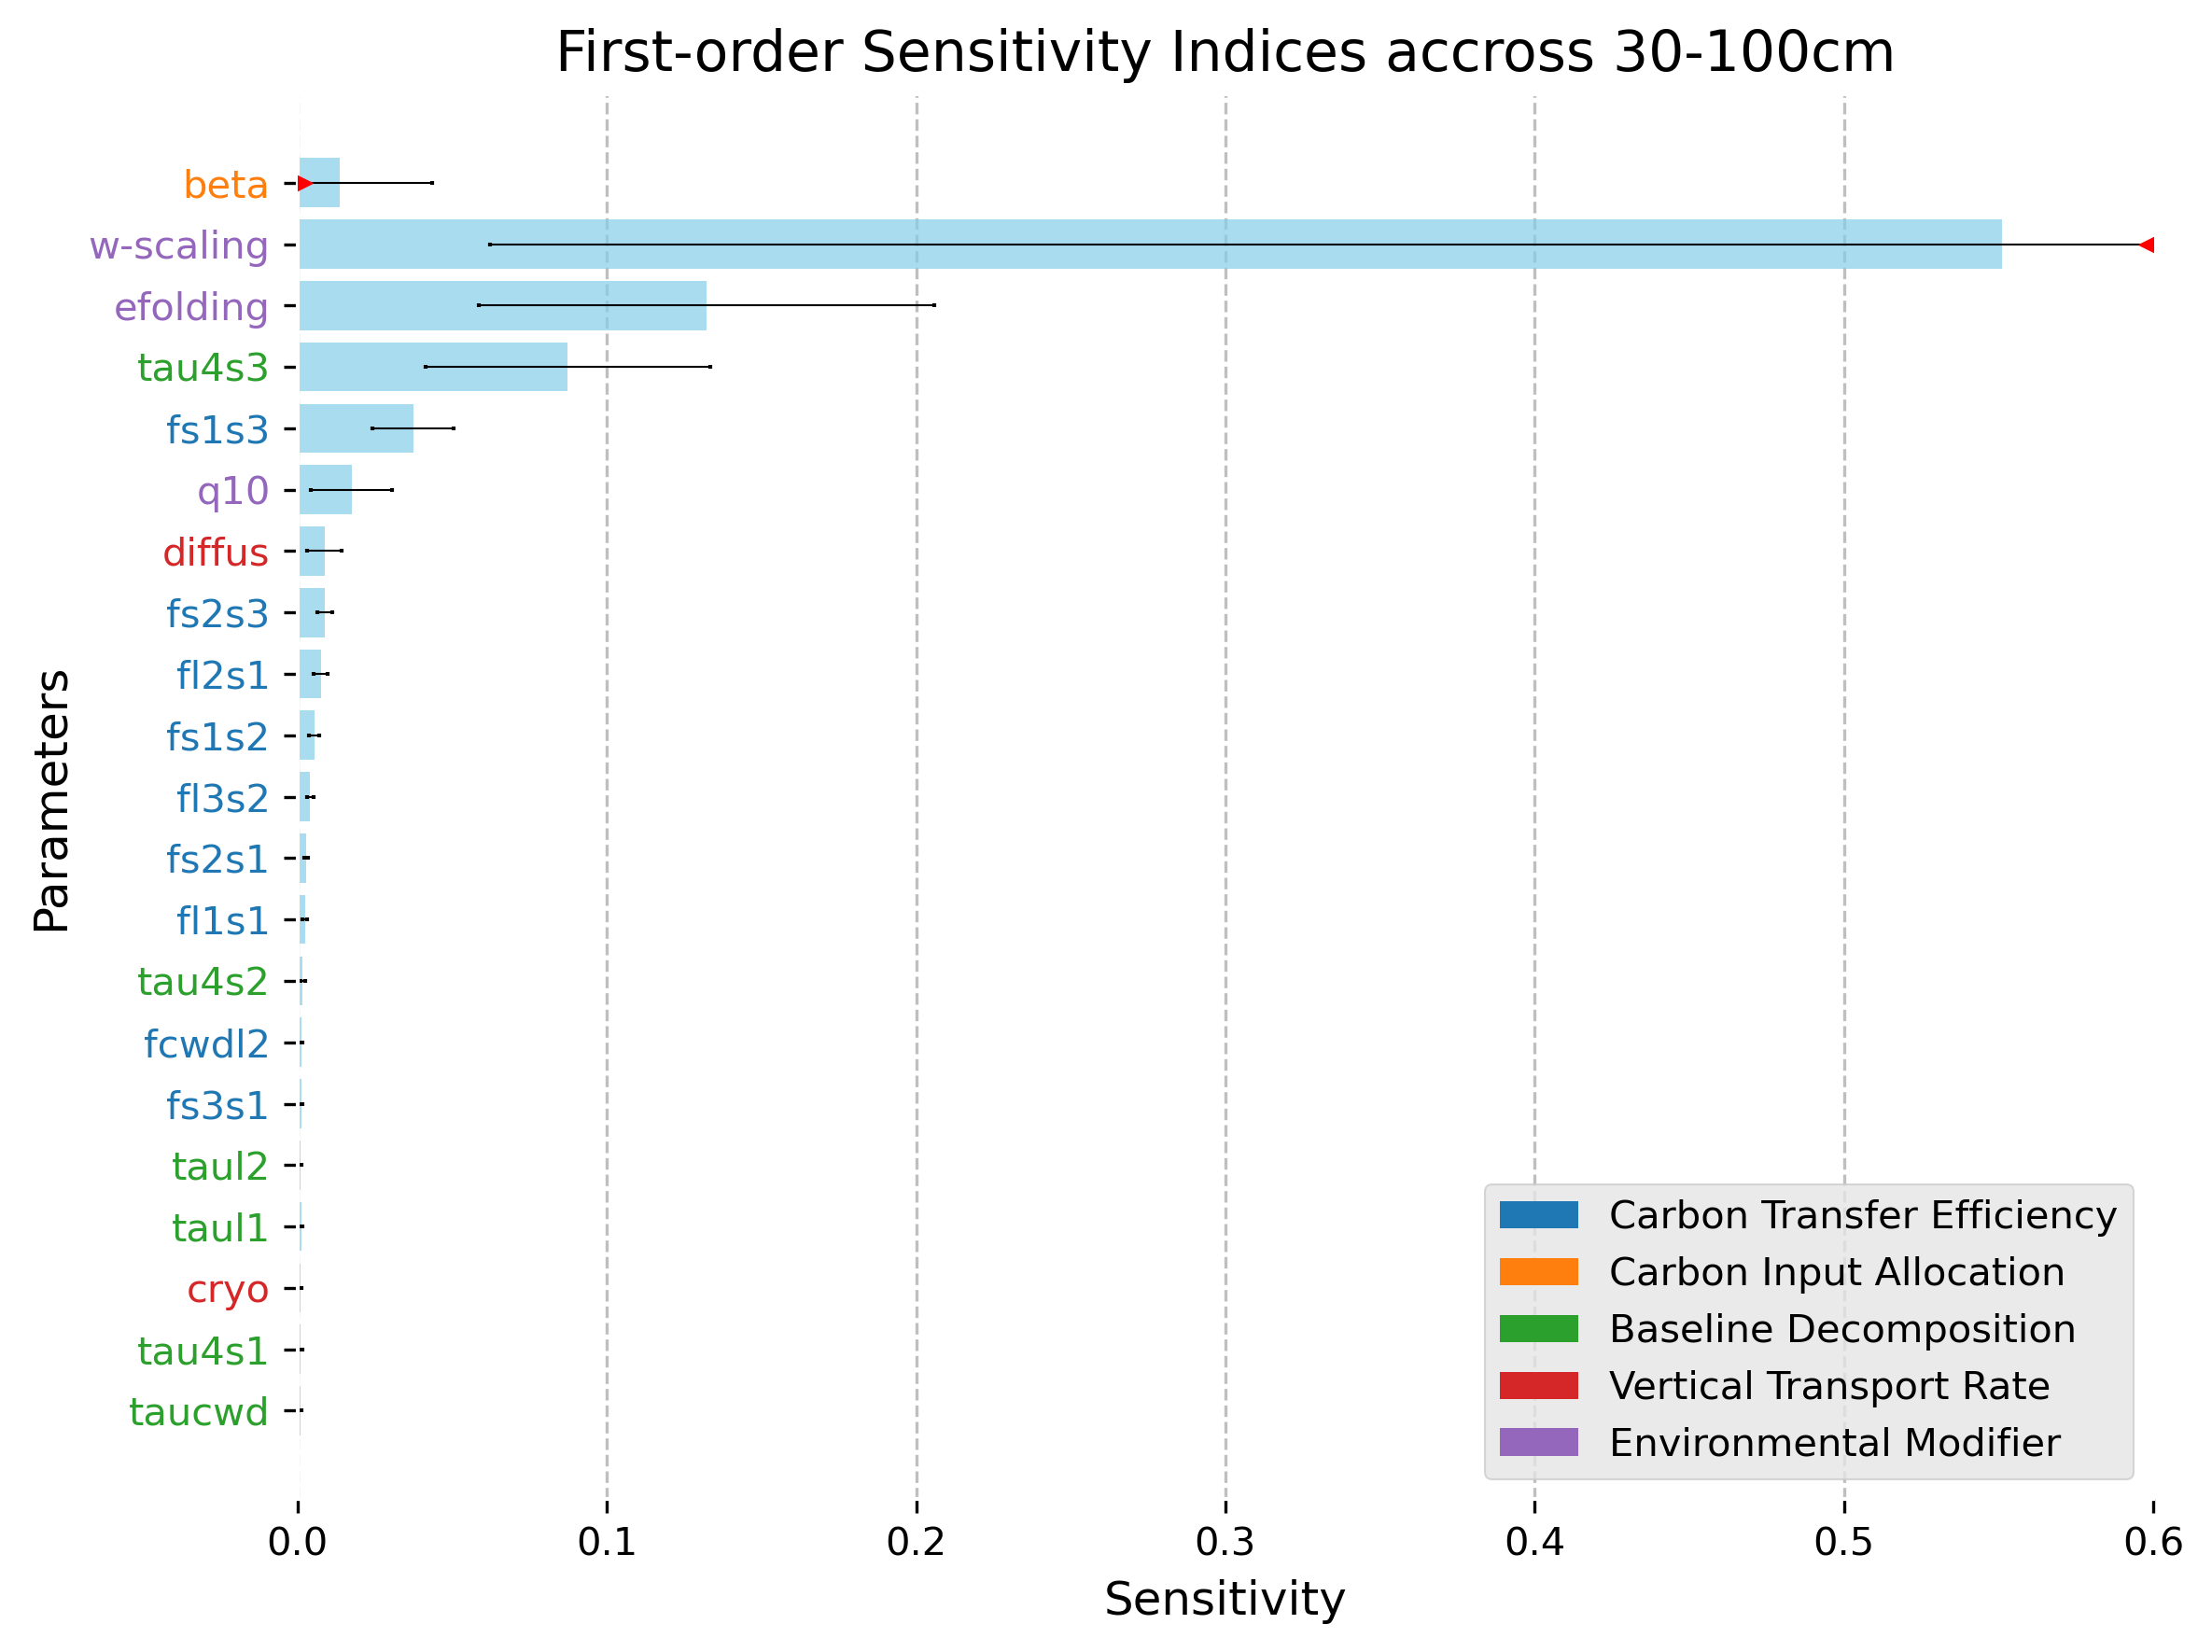

sensitivity_soc_30_100_sensitivity.png has been saved!
parameters            taucwdtau4s1cryotaul1taul2fs3s1fcwdl2tau4s2fl1...
sensitivity_all                                                  1.3656
sensitivity_std                                                2.759012
sensitivity_30_100                                              0.88809
dtype: object


In [5]:
# Load parameter variance from csv and plot the bar chart
for i in range(1, 8):
	if i == 1:
		para_var_30_100 = pd.read_csv(input_dir + 'sensitivity_soc_30_100_sensitivity_' + str(i) + '.csv')
		para_var_30_100 = para_var_30_100.drop(columns = ['Unnamed: 0'])
	else:
		para_var_30_100 = pd.concat([para_var_30_100, pd.read_csv(input_dir + 'sensitivity_soc_30_100_sensitivity_' + str(i) + '.csv').drop(columns = ['Unnamed: 0'])], axis = 1)
# Rename the columns to 0-20
para_var_30_100.columns = range(len(para_names))
# Drop all the rows with NaN and Inf
para_var_30_100 = para_var_30_100.replace([np.inf, -np.inf], np.nan).dropna()
# Calculate the mean value of each column
para_var_30_100_mean = para_var_30_100.mean()
# Create a dataframe to store the mean value and the parameter names
para_var_30_100_mean = pd.DataFrame(para_names, columns = ['parameters'])
para_var_30_100_mean['sensitivity'] = para_var_30_100.mean().values
# Create a dataframe to store the std value and the parameter names
para_var_30_100_std = pd.DataFrame(para_names, columns = ['parameters'])
para_var_30_100_std['sensitivity_std'] = para_var_30_100.std().values
# Merge the two dataframes so that we can plot the second bar chart following the first one's order
para_var_30_100_mean = pd.merge(para_var_all_mean, para_var_30_100_mean, on = 'parameters', how = 'inner', suffixes = ('_all', '_30_100'))
para_var_30_100_plot = pd.merge(para_var_30_100_mean, para_var_30_100_std, on = 'parameters')

# Clipped ends of error bars
lower = para_var_30_100_plot['sensitivity_30_100'] - para_var_30_100_plot['sensitivity_std_y']
upper = para_var_30_100_plot['sensitivity_30_100'] + para_var_30_100_plot['sensitivity_std_y']
x_min = 0.0
x_max = 0.6
lower_clip = np.maximum(lower, x_min)
upper_clip = np.minimum(upper, x_max)
left_err_draw = np.clip(para_var_30_100_plot['sensitivity_30_100'] - lower_clip, 0, None)
right_err_draw = np.clip(upper_clip - para_var_30_100_plot['sensitivity_30_100'], 0, None)
xerr_draw = np.vstack([left_err_draw, right_err_draw])

# Create a horizontal bar chart
fig, ax = plt.subplots(figsize = (8, 6), dpi = 300)
ax.barh(para_var_30_100_plot['parameters'], para_var_30_100_plot['sensitivity_30_100'], alpha = 0.7, color = 'skyblue')
ax.errorbar(para_var_30_100_plot['sensitivity_30_100'], para_var_30_100_plot['parameters'], xerr = para_var_30_100_plot['sensitivity_std_y'], ecolor = 'black', elinewidth = 0.5, capsize = 0.5, fmt = 'none')
# --- Add red dots where clipping happens ---
mask_left_clipped = lower < x_min
mask_right_clipped = upper > x_max

if mask_left_clipped.any():
    	ax.scatter(
		np.full(mask_left_clipped.sum(), x_min),
		para_var_30_100_plot['parameters'][mask_left_clipped],
		color='red',
		s=50,
		zorder=3,
		marker = '>'
	)

if mask_right_clipped.any():
	ax.scatter(
		np.full(mask_right_clipped.sum(), x_max),
		para_var_30_100_plot['parameters'][mask_right_clipped],
		color='red',
		s=50,
		zorder=3,
		marker = '<'
	)

# Add labels and title
ax.set_xlabel('Sensitivity')
ax.set_ylabel('Parameters')
ax.set_title('First-order Sensitivity Indices accross 30-100cm')
ax.set_xlim(0, 0.6)
# Blank background color
ax.set_facecolor('white')
# Text color to black
ax.tick_params(axis = 'x', colors = 'black')
ax.tick_params(axis = 'y', colors = 'black')
# Axis subtitle color to black
ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')
# Add grid lines only for x-axis
ax.xaxis.grid(True, linestyle = '--', which = 'major', color = 'grey', alpha = 0.5)
ax.yaxis.grid(False)

# --- color each y-tick label by its matrix color ---
fig.canvas.draw()
yticklabels = ax.get_yticklabels()
for lab in yticklabels:
	p = lab.get_text()
	lab.set_color(_param_color(p))
		
leg = ax.legend(handles=legend_handles, frameon=True, loc='lower right')
leg._legend_box.align = "left"

plt.tight_layout()
plt.show()
# Save the figure
fig.savefig(data_dir_output + 'sensitivity_soc_30_100_sensitivity.png')
print('sensitivity_soc_30_100_sensitivity.png has been saved!')

# Check the sum of the sensitivity
print(para_var_30_100_mean.sum())

		

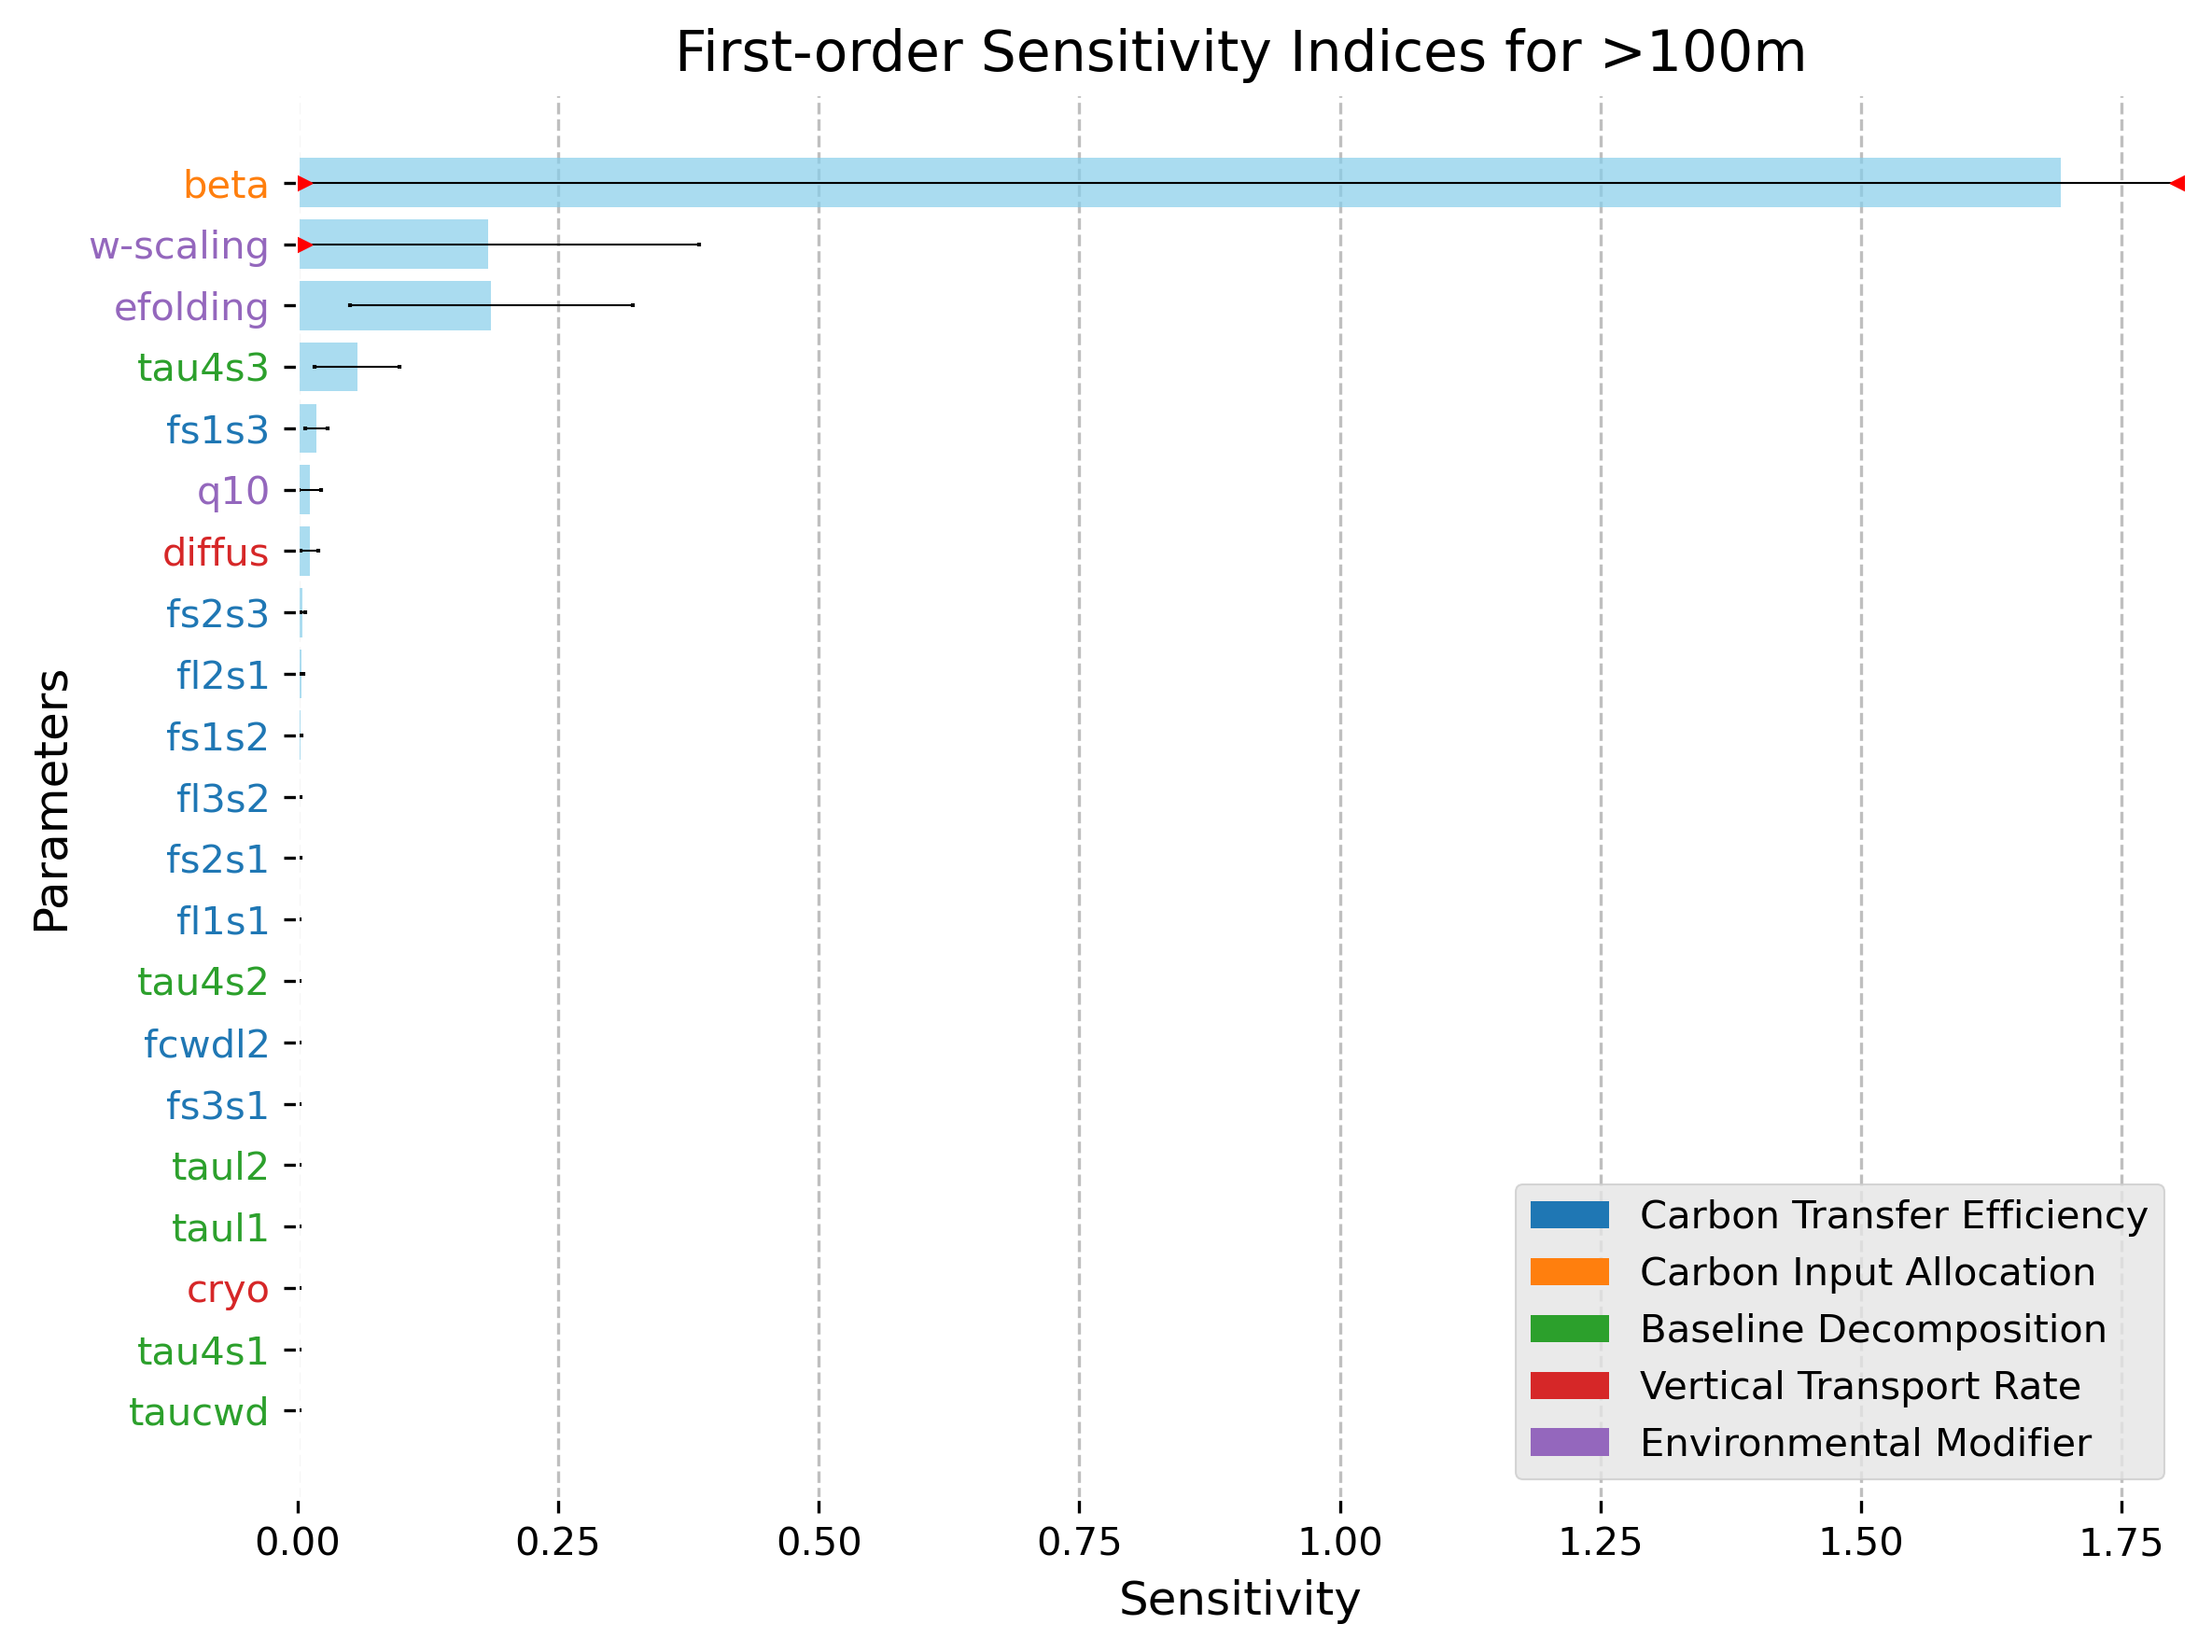

sensitivity_soc_100__sensitivity.png has been saved!
parameters          taucwdtau4s1cryotaul1taul2fs3s1fcwdl2tau4s2fl1...
sensitivity_all                                                1.3656
sensitivity_std                                              2.759012
sensitivity_100_                                             2.184548
dtype: object


In [6]:
# Load parameter variance from csv and plot the bar chart
for i in range(1, 8):
	if i == 1:
		para_var_100_ = pd.read_csv(input_dir + 'sensitivity_soc_100__sensitivity_' + str(i) + '.csv')
		para_var_100_ = para_var_100_.drop(columns = ['Unnamed: 0'])
	else:
		para_var_100_ = pd.concat([para_var_100_, pd.read_csv(input_dir + 'sensitivity_soc_100__sensitivity_' + str(i) + '.csv').drop(columns = ['Unnamed: 0'])], axis = 1)
# Rename the columns to 0-20
para_var_100_.columns = range(21)
# Drop all the rows with NaN and Inf
para_var_100_ = para_var_100_.replace([np.inf, -np.inf], np.nan).dropna()
# Calculate the mean value of each column
para_var_100_mean = para_var_100_.mean()
# Create a dataframe to store the mean value and the parameter names
para_var_100_mean = pd.DataFrame(para_names, columns = ['parameters'])
para_var_100_mean['sensitivity'] = para_var_100_.mean().values
# Create a dataframe to store the std value and the parameter names
para_var_100_std = pd.DataFrame(para_names, columns = ['parameters'])
para_var_100_std['sensitivity_std'] = para_var_100_.std().values
# Merge the two dataframes so that we can plot the second bar chart following the first one's order
para_var_100_mean = pd.merge(para_var_all_mean, para_var_100_mean, on = 'parameters', how = 'inner', suffixes = ('_all', '_100_'))
para_var_100_plot = pd.merge(para_var_100_mean, para_var_100_std, on = 'parameters')

# Clipped ends of error bars
lower = para_var_100_plot['sensitivity_100_'] - para_var_100_plot['sensitivity_std_y']
upper = para_var_100_plot['sensitivity_100_'] + para_var_100_plot['sensitivity_std_y']
x_min = 0.0
x_max = 1.81
lower_clip = np.maximum(lower, x_min)
upper_clip = np.minimum(upper, x_max)
left_err_draw = np.clip(para_var_100_plot['sensitivity_100_'] - lower_clip, 0, None)
right_err_draw = np.clip(upper_clip - para_var_100_plot['sensitivity_100_'], 0, None)
xerr_draw = np.vstack([left_err_draw, right_err_draw])

# Create a horizontal bar chart
fig, ax = plt.subplots(figsize = (8, 6), dpi = 300)
ax.barh(para_var_100_plot['parameters'], para_var_100_plot['sensitivity_100_'], alpha = 0.7, color = 'skyblue')
ax.errorbar(para_var_100_plot['sensitivity_100_'], para_var_100_plot['parameters'], xerr = xerr_draw, ecolor = 'black', elinewidth = 0.5, capsize = 0.5, fmt = 'none')
# --- Add red dots where clipping happens ---
mask_left_clipped = lower < x_min
mask_right_clipped = upper > x_max
if mask_left_clipped.any():
	ax.scatter(
		np.full(mask_left_clipped.sum(), x_min),
		para_var_100_plot['parameters'][mask_left_clipped],
		color='red',
		s=50,
		zorder=3,
		marker = '>'
	)
if mask_right_clipped.any():
	ax.scatter(
		np.full(mask_right_clipped.sum(), x_max),
		para_var_100_plot['parameters'][mask_right_clipped],
		color='red',
		s=50,
		zorder=3,
		marker = '<'
	)

# Add labels and title
ax.set_xlabel('Sensitivity')
ax.set_ylabel('Parameters')
ax.set_title('First-order Sensitivity Indices for >100m')
ax.set_xlim(x_min, x_max)
# Blank background color
ax.set_facecolor('white')
# Text color to black
ax.tick_params(axis = 'x', colors = 'black')
ax.tick_params(axis = 'y', colors = 'black')
# Axis subtitle color to black
ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')
# Add grid lines only for x-axis
ax.xaxis.grid(True, linestyle = '--', which = 'major', color = 'grey', alpha = 0.5)
ax.yaxis.grid(False)

# --- color each y-tick label by its matrix color ---
fig.canvas.draw()
yticklabels = ax.get_yticklabels()
for lab in yticklabels:
	p = lab.get_text()
	lab.set_color(_param_color(p))

leg = ax.legend(handles=legend_handles, frameon=True, loc='lower right')
leg._legend_box.align = "left"

plt.tight_layout()
plt.show()
# Save the figure
fig.savefig(data_dir_output + 'sensitivity_soc_100__sensitivity.png')
print('sensitivity_soc_100__sensitivity.png has been saved!')

# Check the sum of the sensitivity
print(para_var_100_mean.sum())